# ClassLens ASD: Multimodal IEP Intelligence for Autistic Learners

**Gemma 4 Good Hackathon — Kaggle Submission**

ClassLens ASD is a multi-agent AI system that helps special education teachers convert daily classroom work artifacts into IEP-aligned progress data and personalized intervention materials.

### The Problem
- Special ed teachers spend **45-60 minutes per student per week** on manual IEP documentation
- Teachers with 8-12 students lose an entire workday weekly to paperwork
- Existing IEP software handles storage, not intelligence

### The Solution
Four Gemma 4 agents working in sequence:

| Agent | Gemma 4 Feature | What It Does |
|-------|----------------|-------------|
| 🔍 Vision Reader | Multimodal (image+text) | OCR: photo of student work → structured JSON |
| 🎯 IEP Mapper | Function Calling | Maps transcription to IEP goals, records trial data |
| 📊 Progress Analyst | Thinking Mode | Trend detection, regression alerts, explainable reasoning |
| ✏️ Material Forge | Function Calling | Generates 7 output types for teachers, parents, admin |

### Demo Students
Three fictional students with realistic ASD profiles created by Sarah Allan (15+ year special ed teacher):

| Student | Grade | ASD Level | Focus Area |
|---------|-------|-----------|------------|
| Maya | 3 | Level 2 | Communication, self-regulation |
| Jaylen | 1 | Level 3 (non-verbal) | Independence, visual schedules |
| Sofia | 5 | Level 1 | Executive function, writing |

## Setup

Install dependencies and configure the Gemma 4 API.

In [1]:
# Install dependencies
!pip install -q google-genai pydantic python-dotenv Pillow plotly

# On Kaggle: clone the repo. Locally: already in the project.
import os
if os.path.exists('/kaggle'):
    if os.path.exists('classlens-asd'):
        !cd classlens-asd && git pull -q
    else:
        !git clone -q https://github.com/jallanUSF/classlens-asd.git


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import json
import sys
from pathlib import Path
from IPython.display import display, Markdown, Image

# Set project root based on environment
if Path('classlens-asd').exists():
    os.chdir('classlens-asd')  # Kaggle
elif Path('..').resolve().joinpath('core').exists():
    os.chdir('..')  # Local: running from notebooks/

project_root = Path('.').resolve()
sys.path.insert(0, str(project_root))

# Load .env if present
try:
    from dotenv import load_dotenv
    load_dotenv()
except ImportError:
    pass

print(f'Project root: {project_root}')
print(f'Python {sys.version}')

Project root: C:\Projects\ClassLense
Python 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]


In [3]:
# Configure API key
# Option 1: Kaggle Secrets (recommended)
try:
    from kaggle_secrets import UserSecretsClient
    secrets = UserSecretsClient()
    os.environ["GOOGLE_AI_STUDIO_KEY"] = secrets.get_secret("GOOGLE_AI_STUDIO_KEY")
    print("API key loaded from Kaggle Secrets")
except:
    pass

# Option 2: Set directly (for local testing)
# os.environ["GOOGLE_AI_STUDIO_KEY"] = "your-key-here"

# Check if API key is available
api_key = os.getenv("GOOGLE_AI_STUDIO_KEY", "")
USE_REAL_API = bool(api_key) and api_key != "your_api_key_here"

if USE_REAL_API:
    from core.gemma_client import GemmaClient
    client = GemmaClient()
    print(f"Using Gemma 4 API (model: {client.model})")
else:
    from tests.mock_api_responses import MockGemmaClient
    client = MockGemmaClient()
    print("No API key — using MockGemmaClient with realistic demo data")
    print("Set GOOGLE_AI_STUDIO_KEY in Kaggle Secrets for live inference")

Using Gemma 4 API (model: gemma-4-31b-it)


## 1. Load Student Profiles

Each student has a JSON profile with demographics, IEP goals, sensory profile, interests, and trial history. These were designed by Sarah Allan based on real classroom patterns.

In [4]:
# Load all student profiles
students = {}
for json_file in sorted(Path("data/students").glob("*.json")):
    with open(json_file) as f:
        data = json.load(f)
    students[data["student_id"]] = data

for sid, s in students.items():
    goals = ", ".join(g["domain"] for g in s["iep_goals"])
    interests = ", ".join(s["interests"][:2])
    print(f"{s['name']} (Grade {s['grade']}, ASD Level {s['asd_level']})")
    print(f"  Communication: {s['communication_level']}")
    print(f"  Interests: {interests}")
    print(f"  IEP Goals: {goals}")
    print(f"  Trial history: {sum(len(g.get('trial_history',[])) for g in s['iep_goals'])} entries")
    print()

Jaylen (Grade 1, ASD Level 3)
  Communication: non-verbal, uses PECS (Picture Exchange Communication System) and AAC device
  Interests: Thomas the Tank Engine (specifically Gordon and Percy), spinning wheels
  IEP Goals: communication, independence, social_reciprocity
  Trial history: 16 entries

Maya (Grade 3, ASD Level 2)
  Communication: verbal, 3-4 word phrases, can read sight words
  Interests: Jurassic World raptors (specifically Blue the raptor), water play
  IEP Goals: communication, following_directions, self_regulation
  Trial history: 19 entries

Sofia (Grade 5, ASD Level 1)
  Communication: full sentences, advanced reader (reads at 7th grade level), strong vocabulary
  Interests: US Presidents (knows all 47 in order), maps and geography
  IEP Goals: social_communication, executive_function, written_expression
  Trial history: 16 entries



In [5]:
# Explore Maya's profile in detail
maya = students["maya_2026"]
display(Markdown(f"### Maya's Profile"))
display(Markdown(f"**Interests:** {', '.join(maya['interests'])}"))
display(Markdown(f"**Reinforcers:** {', '.join(maya['reinforcers'])}"))
display(Markdown(f"**Sensory seeks:** {', '.join(maya['sensory_profile']['seeks'])}"))
display(Markdown(f"**Sensory avoids:** {', '.join(maya['sensory_profile']['avoids'])}"))
display(Markdown(f"**Calming strategies:** {', '.join(maya['sensory_profile']['calming_strategies'])}"))

print("\nIEP Goals:")
for g in maya["iep_goals"]:
    baseline = g['baseline']['value'] if isinstance(g['baseline'], dict) else g['baseline']
    latest = g['trial_history'][-1]['pct'] if g.get('trial_history') else 'N/A'
    print(f"  [{g['goal_id']}] {g['domain']}: {g['description'][:80]}...")
    print(f"       Baseline: {baseline}% → Latest: {latest}% (Target: {g['target']}%)")

### Maya's Profile

**Interests:** Jurassic World raptors (specifically Blue the raptor), water play, the color purple, counting things

**Reinforcers:** dinosaur stickers, 5 minutes at water table, iPad counting app

**Sensory seeks:** proprioceptive input, deep pressure, water play

**Sensory avoids:** loud sudden noises, fluorescent lighting, certain food textures (mushy foods, vegetables)

**Calming strategies:** weighted lap pad, noise-canceling headphones, fidget cube


IEP Goals:
  [G1] communication: Maya will initiate or respond to peer greetings (verbal or gesture-based) with 8...
       Baseline: 20% → Latest: 80% (Target: 80%)
  [G2] following_directions: Maya will follow two-step verbal directions (without visual supports) with 75% a...
       Baseline: 45% → Latest: 75% (Target: 75%)
  [G3] self_regulation: Maya will reduce the frequency and duration of outbursts (tantrums, crying, verb...
       Baseline: 3.2% → Latest: 100% (Target: 1%)


## 2. Agent 1: Vision Reader (Multimodal OCR)

The Vision Reader uses **Gemma 4's multimodal capability** to read a photo of student work and produce structured JSON. It uses **function calling** to output a schema-conforming transcription.

This replaces the teacher's manual data entry — snap a photo, get structured data.

### Maya's Math Worksheet

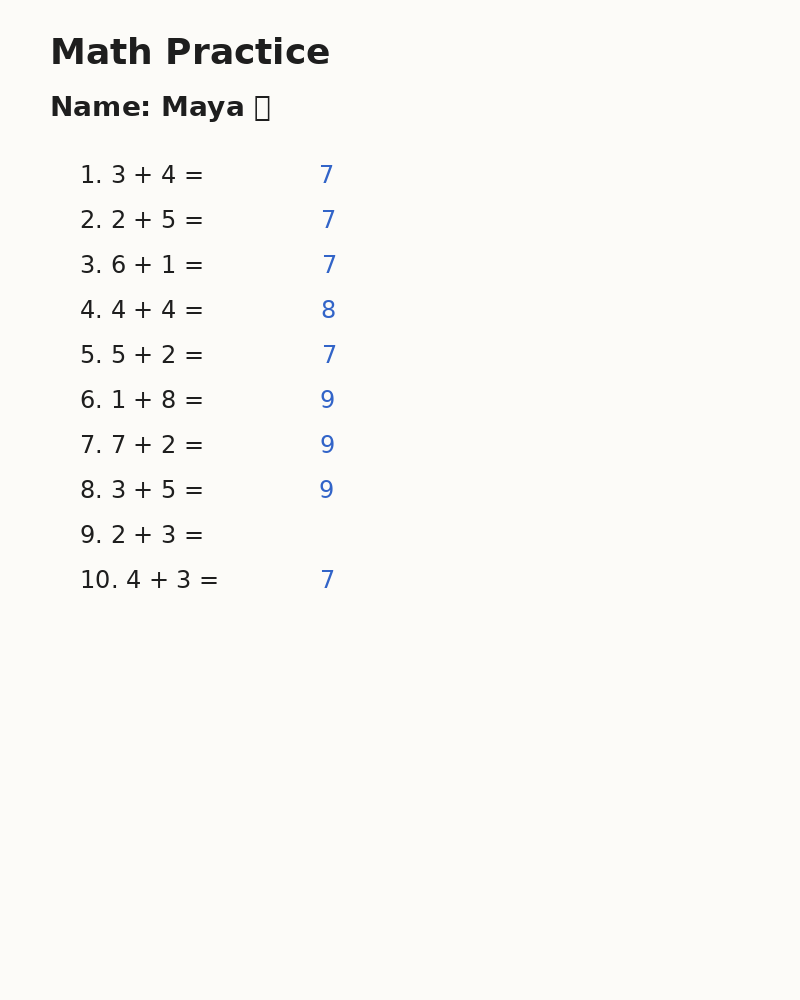

In [6]:
# Show the sample work image
image_path = "data/sample_work/maya_math_worksheet.png"
display(Markdown("### Maya's Math Worksheet"))
display(Image(filename=image_path, width=500))

In [7]:
from agents.vision_reader import VisionReader

vision = VisionReader(client)

transcription = vision.transcribe(
    image_path=image_path,
    student_name="Maya",
    grade=3,
    asd_level=2,
    work_type="worksheet",
    task_description="Math counting and addition worksheet",
)

display(Markdown("### Structured Transcription (via Gemma 4 function calling)"))
print(json.dumps(transcription, indent=2))

### Structured Transcription (via Gemma 4 function calling)

{
  "completed_items": 9,
  "observations": "Maya shows strong proficiency in basic single-digit addition. She completed 9 out of 10 items. One item (problem 9) was skipped entirely, though she proceeded to answer the final problem, suggesting a momentary lapse in attention or an accidental omission rather than a lack of ability. There was one computational error on problem 8 (3+5=9), which may be a counting error. Overall, she is performing well on this task.",
  "items": [
    {
      "item_number": 1,
      "student_response": "7",
      "is_correct": true,
      "correct_response": "7",
      "prompt": "3 + 4 ="
    },
    {
      "correct_response": "7",
      "is_correct": true,
      "prompt": "2 + 5 =",
      "item_number": 2,
      "student_response": "7"
    },
    {
      "student_response": "7",
      "item_number": 3,
      "is_correct": true,
      "correct_response": "7",
      "prompt": "6 + 1 ="
    },
    {
      "item_number": 4,
      "student_response": "8",
      

In [8]:
# Show the Gemma 4 function calling schema used
from schemas.tools import TRANSCRIBE_STUDENT_WORK

display(Markdown("### Function Calling Schema: `transcribe_student_work`"))
display(Markdown("This JSON schema is passed to `generate_with_tools()` — Gemma 4 returns structured output matching this schema."))
print(json.dumps(TRANSCRIBE_STUDENT_WORK, indent=2))

### Function Calling Schema: `transcribe_student_work`

This JSON schema is passed to `generate_with_tools()` — Gemma 4 returns structured output matching this schema.

{
  "name": "transcribe_student_work",
  "description": "Transcribes student work from an image into structured data",
  "parameters": {
    "type": "object",
    "properties": {
      "work_type": {
        "type": "string",
        "enum": [
          "worksheet",
          "tally_sheet",
          "checklist",
          "visual_schedule",
          "free_response"
        ]
      },
      "items": {
        "type": "array",
        "items": {
          "type": "object",
          "properties": {
            "item_number": {
              "type": "integer"
            },
            "prompt": {
              "type": "string"
            },
            "student_response": {
              "type": "string"
            },
            "correct_response": {
              "type": "string"
            },
            "is_correct": {
              "type": "boolean"
            },
            "notes": {
              "type": "string"
            }
          }
        }
      },
      "total_ite

## 3. Agent 2: IEP Mapper (Function Calling)

The IEP Mapper takes the Vision Reader's transcription and **maps it to the student's IEP goals**. It uses Gemma 4 function calling to return structured goal matches with trial data.

This is the core intelligence — connecting raw classroom data to formal IEP tracking.

In [9]:
from agents.iep_mapper import IEPMapper

mapper = IEPMapper(client, data_dir="data")

mapping = mapper.map_to_goals(
    student_id="maya_2026",
    transcription=transcription,
    work_type="worksheet",
)

display(Markdown("### Goal Mapping Result"))
for match in mapping.get("matched_goals", []):
    goal_id = match["goal_id"]
    goal = next((g for g in maya["iep_goals"] if g["goal_id"] == goal_id), {})
    print(f"Goal {goal_id} ({goal.get('domain', '?')})")
    print(f"  Trials: {match.get('trials', '?')} | Successes: {match.get('successes', '?')} | Pct: {match.get('percentage', '?')}%")
    print(f"  Reasoning: {match.get('reasoning', 'N/A')}")
    print()

### Goal Mapping Result

In [10]:
# Show the function calling schema
from schemas.tools import MAP_WORK_TO_GOALS

display(Markdown("### Function Calling Schema: `map_work_to_goals`"))
print(json.dumps(MAP_WORK_TO_GOALS, indent=2))

### Function Calling Schema: `map_work_to_goals`

{
  "name": "map_work_to_goals",
  "description": "Maps transcribed student work to IEP goals with trial data",
  "parameters": {
    "type": "object",
    "properties": {
      "student_id": {
        "type": "string"
      },
      "matched_goals": {
        "type": "array",
        "items": {
          "type": "object",
          "properties": {
            "goal_id": {
              "type": "string"
            },
            "relevance": {
              "type": "string",
              "enum": [
                "primary",
                "secondary"
              ]
            },
            "trials": {
              "type": "integer"
            },
            "successes": {
              "type": "integer"
            },
            "percentage": {
              "type": "number"
            },
            "reasoning": {
              "type": "string"
            }
          }
        }
      }
    },
    "required": [
      "student_id",
      "matched_goals"
    ]
  }
}


## 4. Agent 3: Progress Analyst (Thinking Mode)

The Progress Analyst uses **Gemma 4's thinking mode** (`thinking_budget_tokens=2048`) to perform explainable trend analysis. The thinking chain is preserved so teachers can understand *why* the AI reached its conclusions.

This is critical for trust — special ed teachers need to see the reasoning, not just a number.

In [11]:
from agents.progress_analyst import ProgressAnalyst

analyst = ProgressAnalyst(client, data_dir="data")

# Analyze Maya's communication goal (G1) — the one with the strongest trend
analysis = analyst.analyze(student_id="maya_2026", goal_id="G1")

display(Markdown("### Progress Analysis: Maya Goal G1 (Communication)"))
display(Markdown(f"**Trend:** {analysis.get('trend', 'N/A')}"))
if analysis.get('alert'):
    display(Markdown(f"⚠️ **Alert:** {analysis.get('alert_message', '')}"))

display(Markdown("### Thinking Chain (Gemma 4 Thinking Mode)"))
display(Markdown("_This is the model's step-by-step reasoning — visible to teachers for trust and transparency._"))
print(analysis.get("thinking", "No thinking trace available"))

### Progress Analysis: Maya Goal G1 (Communication)

**Trend:** N/A

### Thinking Chain (Gemma 4 Thinking Mode)

_This is the model's step-by-step reasoning — visible to teachers for trust and transparency._

Maya, 3rd Grade, ASD Level 2. Verbal (3-4 word phrases), reads sight words.
Initiate or respond to peer greetings (verbal/gesture) with 80% accuracy across 10 trials in various settings.
20%
80%
Teacher observation tally.

        *   Mar 15: 3/10 (30%) - Peer buddy start, shy.
        *   Mar 22: 4/10 (40%) - Better with familiar peers.
        *   Mar 29: 6/10 (60%) - Sensory overload (fire drill) but recovery in 1:1.
        *   Apr 01: 7/10 (70%) - Consistent in familiar contexts/morning routine.
        *   Apr 03: 8/10 (80%) - Target met, stickers helping.
        *   Apr 04 (Session 1): 8/10 (80%) - Stable.
        *   Apr 04 (Session 2): 8/10 (80%) - Stable.

    *   *Total Trials:* 10 + 10 + 10 + 10 + 10 + 10 + 10 = 70 trials.
    *   *Total Successes:* 3 + 4 + 6 + 7 + 8 + 8 + 8 = 44 successes.
    *   *Success Rate:* $44 / 70 \approx 62.86\%$.
    *   *Current State:* The most recent three sessions are all at 80%.
    *   *Direction:* Clearly "improving". The trend is a stead

In [12]:
display(Markdown("### Progress Note (Final Output)"))
print(analysis.get("progress_note", "No progress note generated"))

### Progress Note (Final Output)

Maya has made fantastic growth in her social interactions, moving from a 20% baseline to consistently meeting her 80% goal over her last three sessions. She is responding particularly well to the structured morning routine and the use of reinforcer stickers to encourage engagement. It is especially encouraging to see her resilience; despite a sensory-heavy fire drill on March 29th, she was able to recover and continue her upward progress in 1:1 settings.


## 5. Visualize Progress Trends

Plotly charts show trial data over time for each IEP goal. Teachers and parents can see at a glance whether a student is improving, plateauing, or regressing.

In [13]:
import plotly.graph_objects as go

# Plot Maya's goal progress across all 3 goals
fig = go.Figure()

colors = {"G1": "#5B8FB9", "G2": "#8BC34A", "G3": "#FF9800"}

for goal in maya["iep_goals"]:
    history = goal.get("trial_history", [])
    if not history:
        continue
    dates = [h["date"] for h in history]
    pcts = [h["pct"] for h in history]
    
    fig.add_trace(go.Scatter(
        x=dates, y=pcts,
        mode="lines+markers",
        name=f"{goal['goal_id']}: {goal['domain']}",
        line=dict(color=colors.get(goal['goal_id'], '#999'), width=3),
        marker=dict(size=10),
    ))
    
    # Add target line
    fig.add_hline(
        y=goal["target"],
        line_dash="dot",
        line_color=colors.get(goal['goal_id'], '#999'),
        annotation_text=f"{goal['goal_id']} target",
        opacity=0.5,
    )

fig.update_layout(
    title="Maya's IEP Goal Progress Over Time",
    xaxis_title="Date",
    yaxis_title="Success Rate (%)",
    yaxis=dict(range=[0, 105]),
    template="plotly_white",
    height=500,
    font=dict(size=14),
)

fig.show()

## 6. Agent 4: Material Forge (Function Calling)

The Material Forge generates **7 output types** for 3 audiences using Gemma 4 function calling:

| Output | Audience | Purpose |
|--------|----------|--------|
| Lesson Plan | Teacher | IEP-aligned lesson with student interests |
| Tracking Sheet | Teacher | Clipboard-ready data collection form |
| Social Story | Teacher | Carol Gray framework narrative |
| Visual Schedule | Teacher | Step-by-step routine with icons |
| First-Then Board | Teacher | Motivation board using reinforcers |
| Parent Communication | Parents | Warm, jargon-free progress update |
| Admin Report | Administration | Formal progress report for IEP meetings |

In [14]:
from agents.material_forge import MaterialForge

forge = MaterialForge(client, data_dir="data")

# Generate a lesson plan for Maya's communication goal
lesson = forge.generate_lesson_plan(student_id="maya_2026", goal_id="G1")

display(Markdown("### Generated Lesson Plan"))
display(Markdown(f"**Title:** {lesson.get('title', lesson.get('lesson_title', 'N/A'))}"))
display(Markdown(f"**Duration:** {lesson.get('duration', lesson.get('estimated_duration_minutes', 'N/A'))}"))
display(Markdown(f"**Goal:** {lesson.get('objective', 'N/A')}"))

if lesson.get("materials"):
    display(Markdown("**Materials:** " + ", ".join(lesson["materials"])))
if lesson.get("activities"):
    display(Markdown("**Activities:**"))
    for act in lesson["activities"]:
        if isinstance(act, dict):
            print(f"  Step {act.get('step', '?')}: {act.get('description', act)}")
        else:
            print(f"  - {act}")
if lesson.get("sensory_supports"):
    display(Markdown("**Sensory Supports:** " + ", ".join(lesson["sensory_supports"])))

### Generated Lesson Plan

**Title:** Raptor Greetings: Saying 'Hi' with Blue!

**Duration:** 30

**Goal:** Maya will initiate or respond to peer greetings (verbal or gesture-based) to increase her accuracy toward the IEP target of 80% across various settings.

In [15]:
# Generate a social story
story = forge.generate_social_story(
    student_id="maya_2026",
    scenario="greeting peers at school arrival",
    skill="responding to peer greetings",
)

display(Markdown("### Generated Social Story (Carol Gray Framework)"))
display(Markdown(f"**Title:** {story.get('title', 'N/A')}"))

pages = story.get("pages", [])
if pages:
    for i, page in enumerate(pages, 1):
        print(f"  Page {i}: {page}")
else:
    print(json.dumps(story, indent=2))

### Generated Social Story (Carol Gray Framework)

**Title:** Saying Hello at School

{
  "interest_used": "Jurassic World raptors (Blue), purple, counting, and water play",
  "student_id": "Maya_G3_ASD2",
  "vocabulary_level": "3-4 word phrases / sight words",
  "sentences": [
    {
      "text": "Every morning, Maya comes to school.",
      "type": "descriptive"
    },
    {
      "text": "Maya wears her favorite purple backpack.",
      "type": "descriptive"
    },
    {
      "type": "descriptive",
      "text": "Maya can count the steps all the way to her classroom."
    },
    {
      "text": "It is a great day to start school.",
      "type": "affirmative"
    },
    {
      "type": "descriptive",
      "text": "My friends are waiting in the classroom."
    },
    {
      "text": "Sometimes, a friend says, \"Hi Maya!\" or \"Hello!\"",
      "type": "descriptive"
    },
    {
      "text": "When friends say hello, they are being kind.",
      "type": "perspective"
    },
    {
      "type": "perspective",
      "text": "My friends feel happy when they see me."
   

In [16]:
# Generate a parent communication letter
parent_letter = forge.generate_parent_comm(student_id="maya_2026", goal_id="G1")

display(Markdown("### Generated Parent Communication"))
display(Markdown("_Warm, jargon-free progress update for Maya's family._"))
if parent_letter.get('text'):
    print(parent_letter['text'])
else:
    for key in ['greeting', 'highlight', 'data_summary', 'home_activity', 'closing']:
        if parent_letter.get(key):
            print(f"{key.replace('_', ' ').title()}: {parent_letter[key]}")
            print()

### Generated Parent Communication

_Warm, jargon-free progress update for Maya's family._

[School Letterhead]
[Date]

Dear Maya's Family,

I wanted to share some wonderful progress Maya is making! Since we last met, Maya has been working on saying hello or waving to her friends during the school day. Over the past few weeks, I've seen Maya give a friendly wave to a classmate during morning arrival and respond with a smile and a "hi" when a peer greets her during free play. This shows that Maya is building her confidence in making friends and connecting with her classmates!

Here is a look at what we are tracking: our goal is for Maya to initiate or respond to a greeting in 8 out of 10 opportunities. When we started, Maya was doing this about 20% of the time. Now, she is achieving this skill about 74% of the time, and in our most recent observations, she has even hit that 80% mark! It is so exciting to see her trend moving upward so steadily. (I've included a simple progress bar at the bottom of this note to show how close she is to her goal!)

You can help Maya practice the

In [17]:
# Generate an admin progress report
admin_report = forge.generate_admin_report(student_id="maya_2026")

display(Markdown("### Generated Admin Report"))
display(Markdown("_Formal progress report for IEP meetings and administrators._"))
if admin_report.get('text'):
    print(admin_report['text'])
else:
    if admin_report.get('executive_summary'):
        print('Executive Summary:', admin_report['executive_summary'])
        print()
    for gs in admin_report.get('goal_summaries', []):
        print(f"Goal {gs.get('goal_id', '?')}: {gs.get('trend', '?')}")
        print(f"  {gs.get('narrative', '')}")
        print()

### Generated Admin Report

_Formal progress report for IEP meetings and administrators._

Executive Summary: Maya has demonstrated significant progress across all three monitored IEP goals during this reporting period. She has successfully met her targets for peer communication and following multi-step directions, and is showing a strong positive trend in self-regulation and emotional stability.

Goal G1: Improving
  Maya is now consistently engaging with peers during morning transitions and classroom activities.

Goal G2: Improving
  Maya has reached the target for independent auditory processing of two-step instructions.

Goal G3: Improving
  There is a marked increase in Maya's ability to utilize self-regulation tools, leading to a significant decrease in the duration and intensity of outbursts.



In [18]:
# Generate a data tracking sheet
tracking = forge.generate_tracking_sheet(student_id="maya_2026", goal_id="G1")

display(Markdown("### Generated Tracking Sheet"))
display(Markdown("_Clipboard-ready data collection form for classroom use._"))
if tracking.get('text'):
    print(tracking['text'])
else:
    print(f"Title: {tracking.get('sheet_title', tracking.get('title', 'N/A'))}")
    print(f"Measurement: {tracking.get('measurement_type', 'N/A')}")
    if tracking.get('columns'):
        headers = [c.get('header', c) if isinstance(c, dict) else c for c in tracking['columns']]
        print(f"Columns: {' | '.join(headers)}")

### Generated Tracking Sheet

_Clipboard-ready data collection form for classroom use._

Title: Peer Greeting Initiation & Response Tracker - Maya
Measurement: trial_percentage
Columns: Date | Time/Session | Trial # | Behavior/Response (What did Maya do?) | Outcome (I / VP / MP / N) | Notes (Setting/Context)


## 7. Full Pipeline: End-to-End

The pipeline chains all four agents: **Image → Transcription → Goal Mapping → Analysis**.

Material generation is separate (invoked from the UI) because teachers choose what to generate.

### Processing: Maya's Peer Interaction Tally

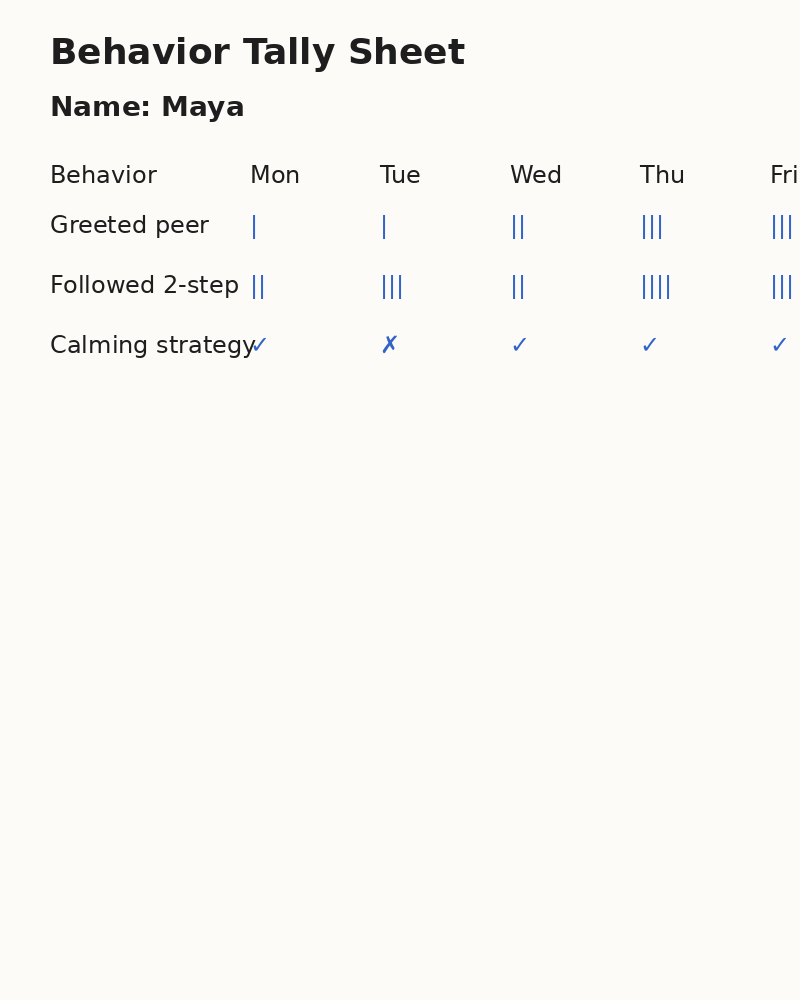

In [19]:
from core.pipeline import ClassLensPipeline

pipeline = ClassLensPipeline(client=client, data_dir="data")

# Process Maya's behavior tally sheet
display(Markdown("### Processing: Maya's Peer Interaction Tally"))
display(Image(filename="data/sample_work/maya_behavior_tally.png", width=500))

In [20]:
result = pipeline.process_work_artifact(
    student_id="maya_2026",
    image_path="data/sample_work/maya_behavior_tally.png",
    work_type="tally_sheet",
    subject="communication",
    date="2026-04-03",
)

display(Markdown("### Pipeline Result Summary"))
n_goals = len(result.get('goal_mapping', {}).get('matched_goals', []))
n_analyses = len(result.get('analyses', []))
n_alerts = len(result.get('alerts', []))
print(f"Goals matched: {n_goals}")
print(f"Analyses generated: {n_analyses}")
print(f"Alerts: {n_alerts}")

display(Markdown("### Transcription"))
print(json.dumps(result["transcription"], indent=2, default=str)[:1000])

### Pipeline Result Summary

Goals matched: 2
Analyses generated: 2
Alerts: 0


### Transcription

{
  "student_name": "Maya",
  "work_type": "tally_sheet",
  "subject": "communication",
  "raw_text": "Maya - Peer Interaction Behavior Tally - Week of 2026-03-29 to 2026-04-03\n---\nMonday (03/29): III (3/10 greetings) - Fire drill disrupted; recovered well\nTuesday (03/30): IIII (4/10) - Morning routine establishing pattern\nWednesday (03/31): IIII I (6/10) - Better with familiar peers\nThursday (04/01): IIII II (7/10) - Consistent responses in greeting time\nFriday (04/02): IIII III (8/10) - **GOAL MET** Peer buddy reinforcement working\n---\nReinforcer used: Dinosaur stickers (5 per successful greeting)\nContext: Classroom arrivals, lunch, specials, free play\nTeacher observations: Maya shows clear preference for familiar peers. Sticker reinforcer highly motivating. Recommendation: Expand to new peer contexts.",
  "task_items": [
    {
      "item": "Monday greetings",
      "response": "3/10",
      "correct": false
    },
    {
      "item": "Tuesday greetings",
      "response":

In [21]:
display(Markdown("### Goal Mapping"))
for match in result.get("goal_mapping", {}).get("matched_goals", []):
    print(f"  {match['goal_id']}: {match.get('percentage', '?')}% — {match.get('reasoning', '')}")

display(Markdown("### Analyses"))
for a in result.get("analyses", []):
    print(f"  {a.get('goal_id', '?')}: trend={a.get('trend', '?')}")
    if a.get("thinking"):
        print(f"    Thinking: {a['thinking'][:200]}...")

### Goal Mapping

  G1: 80% — Peer greeting tally directly measures communication goal
  G2: 75% — Math accuracy and engagement indicate direction-following progress


### Analyses

  G1: trend=stable
    Thinking: Let me analyze Maya's trial data step by step:
1. Initial baseline (March 15): 3/10 successes (30%)
2. Second observation (March 22): 4/10 (40%) - slight improvement
3. Third observation (March 29): 6...
  G2: trend=stable
    Thinking: Let me analyze Maya's trial data step by step:
1. Initial baseline (March 15): 3/10 successes (30%)
2. Second observation (March 22): 4/10 (40%) - slight improvement
3. Third observation (March 29): 6...


## 8. All Three Students

Run the pipeline for Jaylen and Sofia too — showing the system handles diverse ASD profiles.

### Jaylen's Visual Schedule Checklist

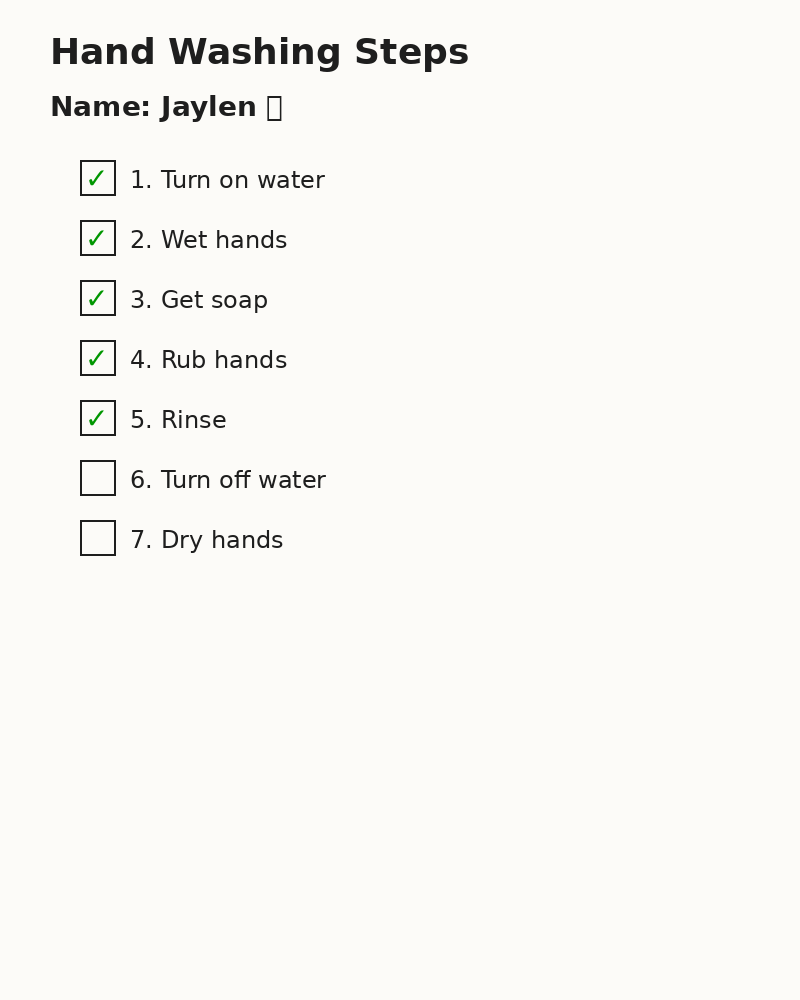

Goals matched: 1
  G1: trend=stable


In [22]:
# Jaylen: non-verbal, Level 3, task checklist
display(Markdown("### Jaylen's Visual Schedule Checklist"))
display(Image(filename="data/sample_work/jaylen_task_checklist.png", width=500))

jaylen_result = pipeline.process_work_artifact(
    student_id="jaylen_2026",
    image_path="data/sample_work/jaylen_task_checklist.png",
    work_type="checklist",
    subject="daily_living",
    date="2026-04-03",
)

print(f"Goals matched: {len(jaylen_result.get('goal_mapping', {}).get('matched_goals', []))}")
for a in jaylen_result.get("analyses", []):
    print(f"  {a.get('goal_id', '?')}: trend={a.get('trend', '?')}")

### Sofia's Reflective Writing Sample

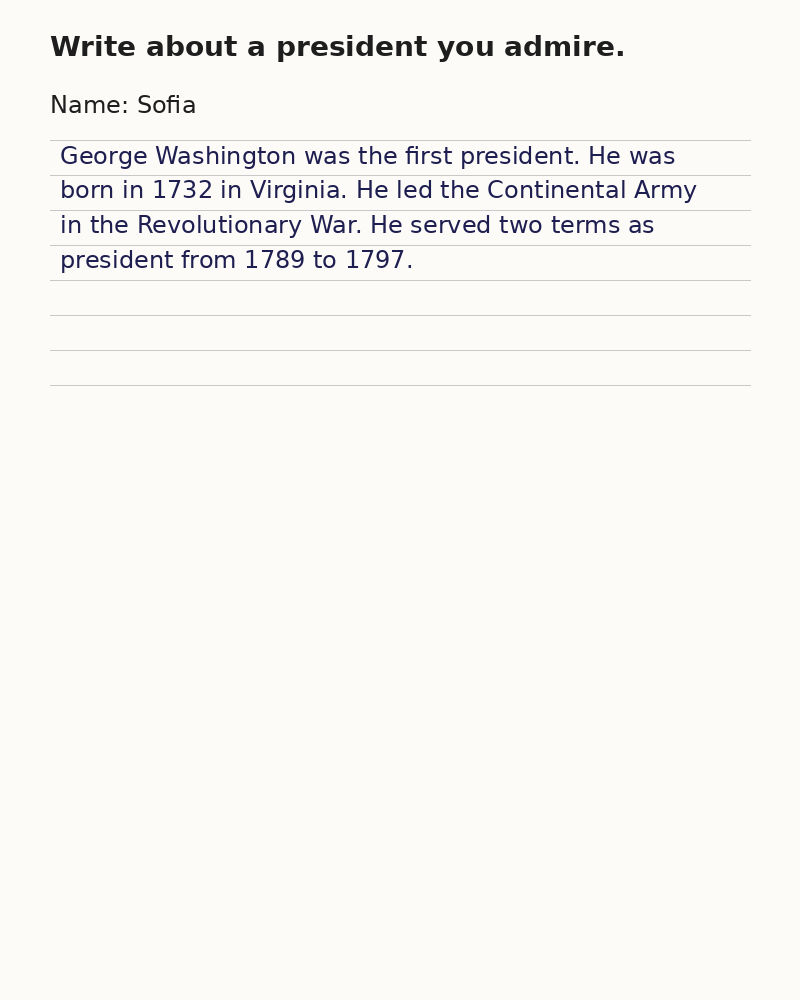

Goals matched: 1
  G1: trend=stable


In [23]:
# Sofia: Level 1, gifted writer, free response
display(Markdown("### Sofia's Reflective Writing Sample"))
display(Image(filename="data/sample_work/sofia_writing_sample.png", width=500))

sofia_result = pipeline.process_work_artifact(
    student_id="sofia_2026",
    image_path="data/sample_work/sofia_writing_sample.png",
    work_type="free_response",
    subject="writing",
    date="2026-04-03",
)

print(f"Goals matched: {len(sofia_result.get('goal_mapping', {}).get('matched_goals', []))}")
for a in sofia_result.get("analyses", []):
    print(f"  {a.get('goal_id', '?')}: trend={a.get('trend', '?')}")

## 9. Architecture Deep Dive

### How We Use Gemma 4's Three Key Features

**1. Multimodal (Vision Reader)**
```python
# core/gemma_client.py — generate_multimodal()
contents = [
    types.Part.from_bytes(data=image_bytes, mime_type=mime_type),
    types.Part.from_text(text=prompt),
]
response = client.models.generate_content(model=model, contents=contents)
```

**2. Function Calling (Vision Reader, IEP Mapper, Material Forge)**
```python
# core/gemma_client.py — generate_with_tools()
config = types.GenerateContentConfig(
    tools=tools,
    tool_config=types.ToolConfig(
        function_calling_config=types.FunctionCallingConfig(mode="AUTO")
    ),
)
# Returns: {"function": name, "args": {...}}
```

**3. Thinking Mode (Progress Analyst)**
```python
# core/gemma_client.py — generate_with_thinking()
config = types.GenerateContentConfig(
    thinking_config=types.ThinkingConfig(thinking_budget_tokens=2048),
)
# Returns: {"thinking": reasoning_chain, "output": final_response}
```

### Agent Pipeline Flow
```
Photo of student work
       │
       ▼
┌──────────────┐
│ Vision Reader │  ← Gemma 4 multimodal + function calling
│ (Agent 1)     │  → Structured transcription JSON
└──────┬───────┘
       │
       ▼
┌──────────────┐
│ IEP Mapper   │  ← Gemma 4 function calling
│ (Agent 2)    │  → Goal matches + trial data recorded
└──────┬───────┘
       │
       ▼
┌───────────────┐
│ Progress      │  ← Gemma 4 thinking mode
│ Analyst (3)   │  → Trend analysis + explainable reasoning
└──────┬────────┘
       │
       ▼
┌───────────────┐
│ Material      │  ← Gemma 4 function calling
│ Forge (4)     │  → 7 output types × 3 audiences
└───────────────┘
```

## 10. Impact & What's Next

### Time Savings
| Task | Before ClassLens | After ClassLens |
|------|-----------------|----------------|
| Read & transcribe student work | 10-15 min/artifact | 30 seconds |
| Map to IEP goals & record trials | 15-20 min | Automatic |
| Write progress notes | 10-15 min/goal | 1 click |
| Create lesson plans | 30-45 min | 1 click |
| Draft parent communications | 15-20 min | 1 click + review |
| **Total per student per week** | **45-60 min** | **~5 min** |

### Design Principles
- **Teacher-in-the-loop:** Every output has approve/edit/regenerate. Nothing auto-sends.
- **ASD-friendly:** Predictable layouts, calm colors, concrete vocabulary
- **Privacy-first:** FERPA-aware design, no student PII in API calls, local data storage
- **Pre-baked demo:** All sample results cached — demo never waits for API

### Links
- **GitHub:** [jallanUSF/classlens-asd](https://github.com/jallanUSF/classlens-asd)
- **Live Demo:** See Streamlit app deployment
- **Video:** See competition submission

---

*Built by Jeff & Sarah Allan for the Gemma 4 Good Hackathon 2026.*

*ClassLens ASD: Reclaiming teacher time, transforming student outcomes.*